<h3>1. Data Cleaning & Preprocessing</h3>

* Load the dataset and check for missing values.
* Filled missing Age values with Median

In [37]:
import pandas as pd

df = pd.read_csv('Titanic_Data.csv')
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [38]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


* Handling missing Embarked values by filling with the most common port.

In [39]:
common_value = df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(common_value)
df['Embarked'].isnull().sum()

np.int64(0)

* Droping unnecessary columns like Name, Ticket, Cabin for visualization purposes.

In [40]:
df=df.drop(['Name','Ticket','Cabin'], axis=1)
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  , 28.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  ,  8.  ,
       19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  ,
       29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 ,
       20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  , 60.  ,
       10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,
       24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

<h3>2. Univariate Analysis
</h3>

* Plotting the distribution of Age using a histogram and a KDE plot

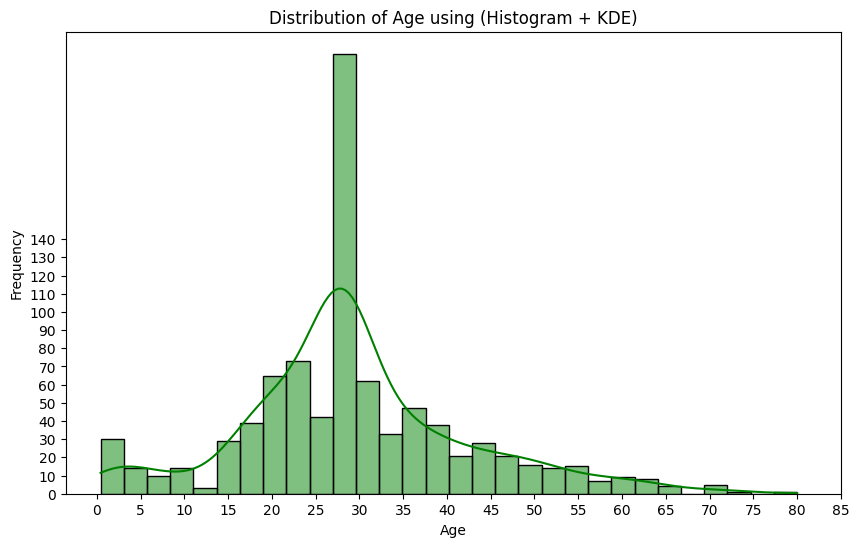

In [41]:
# We need matplotlib and seaborn for it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6), dpi=100) #for defining size of figure
sns.histplot(df['Age'], kde=True, color='green', bins=30)

plt.title('Distribution of Age using (Histogram + KDE)')
plt.xlabel('Age')
plt.xticks(range(0,90,5))
plt.yticks(range(0,150,10))
plt.ylabel('Frequency')
plt.show()

* Plot the count of passengers by Sex using a bar chart.

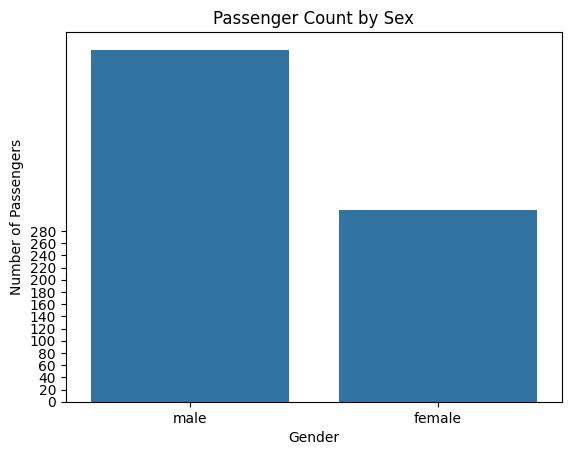

In [42]:
# plt.figure(figsize=(8,5))
sns.countplot(x='Sex', data = df)
plt.title('Passenger Count by Sex')
plt.xlabel('Gender')
plt.yticks(range(0,300,20))
plt.ylabel('Number of Passengers')

plt.show()

* Show the distribution of Fare using a boxplot.


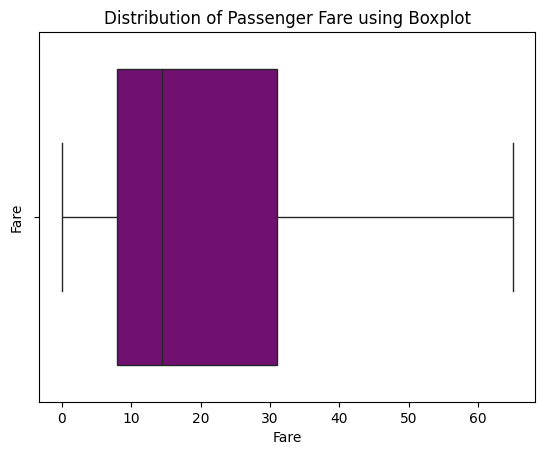

In [43]:
sns.boxplot(x=df['Fare'],color='purple', showfliers=False)
plt.title('Distribution of Passenger Fare using Boxplot')
plt.ylabel('Fare')
plt.show()

<h3>3. Bivariate Analysis</h3>

* Compare survival rate across Sex using a countplot

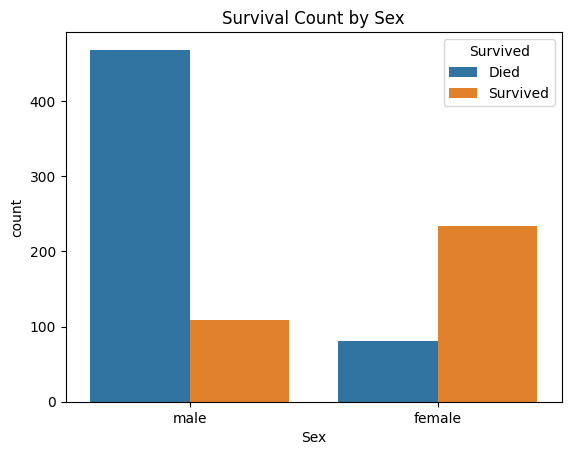

In [ ]:
df['Survived'] = df['Survived'].map({0: 'Died', 1: 'Survived'}) # 0's and 1's look ugly
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Sex")
plt.show()


* Compare Pclass vs Fare using a boxplot.

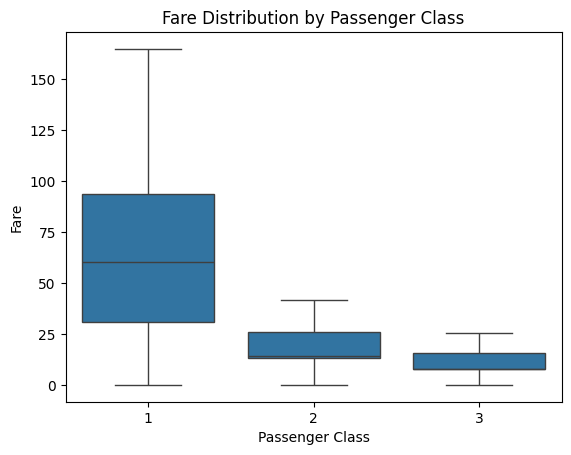

In [47]:
sns.boxplot(x='Pclass',y='Fare',data=df,showfliers=False)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()


* Visualize Age vs Fare using a scatter plot, color-coded by Survived

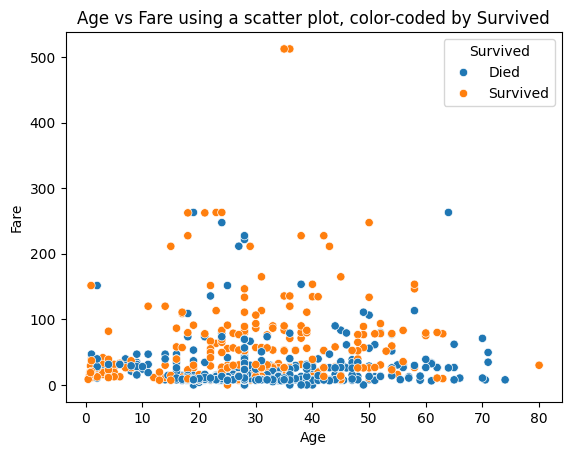

In [48]:
sns.scatterplot(x='Age',y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare using a scatter plot, color-coded by Survived")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()